# Lecture 9A
1. Thinking in Terms of Agent and Environment (Lecture 9A)
Choose one example of an AI system that must make decisions over time, such as a robot, a game-playing system, a navigation tool, or a recommendation system.

Write a short response in which you describe the problem using the basic agent–environment framework from this lecture. Identify the agent, the environment, the possible actions, the states or information the agent should pay attention to, and the rewards or goals that would guide behavior. Then explain why this is a sequential decision-making problem rather than a one-step prediction problem, and briefly discuss how a policy would help the agent decide what to do over time. If relevant, comment on why future rewards might matter more or less than immediate rewards.

This activity is meant to help you translate a real-world AI task into the early language of states, actions, rewards, and policies that will support the formal MDP framework in the next lecture.

## Response 1
- In the healthcare space, medication management is a significant area with many innovative solutions designed to ensure the safe administration of medications. The mantra frequently used is the 5 R's: right patient, right drug, right dose, right route, and right time. Most intelligent medication delivery systems today use static safety definitions and still require clinical intervention. However, a newer type of system, termed "closed-loop," is emerging in the field. These systems vary widely in how they are implemented and how autonomous they truly are, but with AI becoming increasingly prevalent, the industry is moving toward more autonomous systems.
- The system I will describe is a closed-loop medication delivery system that uses integrated physiological sensors to manage medication dosage and fluid delivery rate to a patient.
### PEAS
- Performance: maintain the patient's physiological measures within a safe target range, deliver the correct medication and fluid dose, avoid overmedication or undermedication, and reduce adverse events while supporting the 5 R's of medication safety.
- Environment: the patient, the patient's changing physiology, the hospital or clinical care setting, medication orders, infusion equipment, and any outside factors that may affect how the patient responds to treatment.
- Actuators: adjust infusion rates, increase or decrease medication dosage, deliver fluids, pause or stop delivery, and send alerts to a clinician when the system detects uncertainty or danger.
- Sensors: vital-sign monitors, medication pump readings, blood chemistry or lab values, patient identification data, time since last dose, and other physiological sensors that indicate how the patient is responding.

In this system, the agent is the AI controller inside the closed-loop medication delivery system. The environment is the patient and the surrounding clinical setting. The possible actions include increasing, decreasing, pausing, or resuming a medication or fluid infusion, as well as alerting a clinician when intervention is needed. The states or information the agent should pay attention to include current vital signs, recent trends in those vital signs, medication history, lab results, physician orders, and any signs that the patient is improving or deteriorating. The main goal or reward is to keep the patient stable and safe while delivering effective treatment with as few complications as possible.

This is a sequential decision-making problem rather than a one-step prediction problem because each action changes the patient's future condition. For example, increasing a medication dose may improve a physiological measure in the short term, but it can also create side effects or require adjustments later. The agent must therefore consider not only the current patient state but also how that state may evolve over time in response to treatment.

A policy would help the agent decide what to do by mapping the patient's observed state to an action at each moment. If the patient's measurements remain within a safe range, the policy may keep the current rate unchanged. If the patient begins to drift outside the target range, the policy may recommend a gradual increase or decrease in medication or fluid delivery. Future rewards matter greatly in this setting because a decision that seems beneficial immediately may be harmful later. A good policy must balance immediate correction with long-term patient safety and overall clinical outcome.


# Lecture 9B
Revisit the same sequential decision problem you used in Activity #1, or choose another simple real-world example, such as managing inventory in a small store or deciding how a delivery drone should move under uncertain weather conditions. In Module 9A, you identified the problem from an agent–environment perspective. In this activity, take that same example one step further by expressing it more formally as a Markov Decision Process (MDP). Define the problem in terms of its states, actions, transition behavior, and reward structure. Then explain whether your state definition appears to satisfy the Markov property, and describe what the state value and action value would mean in your example. Conclude with 4–6 sentences explaining how the Bellman equation represents long-term decision quality in this setting and how this formal MDP view goes beyond the more intuitive description from Module 9A.

## Response 2
- I am using the same example from Activity 1. The formalism of the MDP framework is useful because it makes explicit how the system moves from one clinical condition to another over time in response to treatment decisions.

- The state should represent the patient's clinically relevant condition at a given time. For this problem, that state could include current vital signs, short-term trends in those vital signs, current infusion settings, recent medication and fluid history, relevant lab values, patient-specific safety constraints, and the therapeutic target range the system is trying to maintain. The actions are the available control decisions, such as increasing the infusion rate, decreasing it, maintaining the current rate, pausing delivery, resuming delivery, or escalating to a clinician when the situation moves outside the system's confidence or safety limits.

- The transition behavior is inherently stochastic because a patient's physiological response is not perfectly predictable, even when the same action is taken in a clinically similar state. A small increase in medication may stabilize one patient, while in another patient it may have a delayed effect or produce an overshoot because of metabolism, comorbidities, or interactions with other therapies. The reward structure should therefore reflect both treatment effectiveness and safety. A reasonable reward function would assign positive reward when the patient remains within the desired physiological range and negative reward when the patient drifts outside that range, experiences instability, receives an unsafe dose, or requires emergency intervention. It may also be appropriate to include a modest penalty for unnecessarily aggressive control changes so that the system does not "chase noise" and create oscillatory behavior. It should be noted that this transistion behavior would not be acceptable in a true clinical environment and only applicable in a training setting. A commercialized algorithm would be far more stable.

- This state definition appears to satisfy the Markov property only if the state includes enough information to summarize everything clinically relevant about the patient's near-term future. If the state only included the current vital signs at a single instant, it would probably not be Markov, because delayed pharmacologic effects and recent dose history clearly matter. However, if the state is expanded to include recent trends, dose history, timing information, and the major patient-specific variables that influence response, then it becomes a much more defensible approximation of a Markov state. In practice, many healthcare control problems use this kind of approximate Markov representation rather than assuming that the raw instantaneous measurement alone is sufficient.

- In this MDP, the state value would represent the expected long-term clinical benefit of being in a particular patient state and then following the policy from that point forward. A high-value state would be one in which the patient is stable, within target range, and unlikely to experience an adverse event if the controller continues behaving appropriately. The action value is even more specific: it represents the expected long-term value of taking one particular action in the current state and then following the policy afterward. For example, if a patient's blood pressure is trending downward, the action value would help distinguish whether increasing a vasopressor infusion now has better long-term consequences than waiting, decreasing fluids, or escalating to a clinician.

- The Bellman equation captures long-term decision quality by expressing the value of a state as the combination of immediate reward and the expected value of the next state that follows. In this medication delivery setting, that matters because a dosing decision should never be judged only by whether it improves the next reading; it should be judged by whether it improves the patient's trajectory over time. Traditionally, this is something a clinician does judgement wise based on experience. The Bellman view therefore formalizes the idea that good control is not just about immediate correction, but about making the present choice that sets up safer and more effective future states. It also gives a good way to compare actions under uncertainty, since each action is evaluated through both its direct clinical effect and its downstream consequences. Compared with the simpler agent-environment description in my first response, the MDP formulation is more rigorous because it specifies exactly what the system knows, what it can do, how the world may respond, and how long-term success is measured.


# Lecture 9C
3. Value Iteration and Policy Extraction (Lecture 9C)
In this activity, apply value iteration to a small Markov Decision Process and use the resulting values to determine the best action in each state.

Consider the following MDP:

- States: S1, S2, S3, Goal
- Actions available:
    - From S1:
        - a -> S2 with reward 2
        - b -> S3 with reward 1
    - From S2:
        - a -> Goal with reward 5
        - b -> S3 with reward 0
    - From S3:
        - a -> Goal with reward 3
        - b -> S2 with reward 1
- Goal is a terminal state with value 0.
- Discount factor: 
- Assume all state values are initialized to 0.

Perform two iterations of value iteration for states S1, S2, and S3. Then, based on your updated values after the second iteration, identify the best action in each non-terminal state. In a short paragraph, explain how this activity illustrates Bellman optimality and how value iteration supports model-based planning in MDPs.

## Response 3


Assumed discount factor (gamma): 0.9

Iteration 0 values:
  S1: 0.00
  S2: 0.00
  S3: 0.00
  Goal: 0.00

Iteration 1 values:
  S1: 2.00
  S2: 5.00
  S3: 3.00
  Goal: 0.00

Iteration 2 values:
  S1: 6.50
  S2: 5.00
  S3: 5.50
  Goal: 0.00

Best action in each non-terminal state after iteration 2:
  S1: a
    action a: 6.50
    action b: 5.95

  S2: a
    action a: 5.00
    action b: 4.95

  S3: b
    action a: 3.00
    action b: 5.50



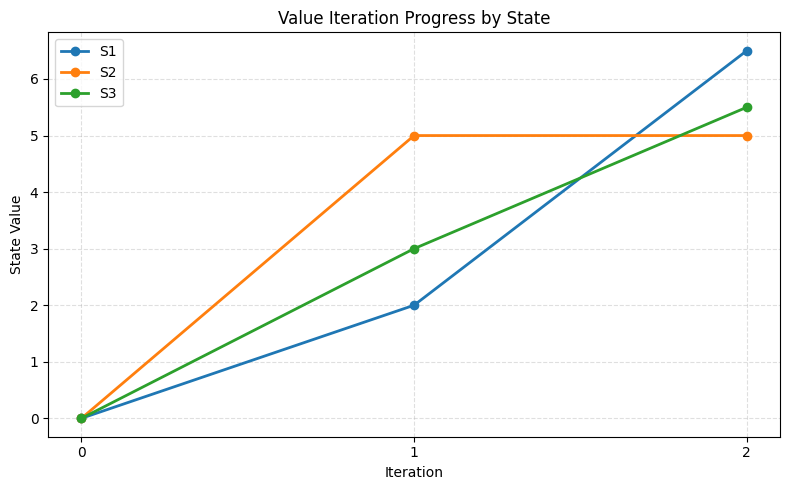

In [1]:
# Lecture 9C: Value iteration for a small MDP
import matplotlib.pyplot as plt

DISCOUNT_FACTOR = 0.9
NUM_ITERATIONS = 2

states = ["S1", "S2", "S3", "Goal"]
non_terminal_states = ["S1", "S2", "S3"]

transitions = {
    "S1": {
        "a": {"next_state": "S2", "reward": 2},
        "b": {"next_state": "S3", "reward": 1},
    },
    "S2": {
        "a": {"next_state": "Goal", "reward": 5},
        "b": {"next_state": "S3", "reward": 0},
    },
    "S3": {
        "a": {"next_state": "Goal", "reward": 3},
        "b": {"next_state": "S2", "reward": 1},
    },
    "Goal": {},
}


def run_value_iteration(states, non_terminal_states, transitions, gamma, num_iterations):
    # Start with all state values initialized to zero.
    values = {state: 0.0 for state in states}
    history = [values.copy()]

    for _ in range(num_iterations):
        # Use a copy so each iteration updates all states synchronously.
        new_values = values.copy()

        for state in non_terminal_states:
            action_returns = {}

            for action, outcome in transitions[state].items():
                next_state = outcome["next_state"]
                reward = outcome["reward"]
                # Bellman update: immediate reward plus discounted next-state value.
                action_returns[action] = reward + gamma * values[next_state]

            # Keep the best available action value for this state.
            new_values[state] = max(action_returns.values())

        values = new_values
        history.append(values.copy())

    return history


def extract_policy(non_terminal_states, transitions, values, gamma):
    action_values = {}
    best_actions = {}

    for state in non_terminal_states:
        action_values[state] = {}

        for action, outcome in transitions[state].items():
            next_state = outcome["next_state"]
            reward = outcome["reward"]
            action_values[state][action] = reward + gamma * values[next_state]

        best_actions[state] = max(action_values[state], key=action_values[state].get)

    return action_values, best_actions


history = run_value_iteration(
    states=states,
    non_terminal_states=non_terminal_states,
    transitions=transitions,
    gamma=DISCOUNT_FACTOR,
    num_iterations=NUM_ITERATIONS,
)

# Use the values after the second iteration to identify the best action in each state.
final_values = history[-1]
action_values, best_actions = extract_policy(
    non_terminal_states=non_terminal_states,
    transitions=transitions,
    values=final_values,
    gamma=DISCOUNT_FACTOR,
)

print(f"Assumed discount factor (gamma): {DISCOUNT_FACTOR}\n")

for iteration_number, value_map in enumerate(history):
    print(f"Iteration {iteration_number} values:")
    for state in states:
        print(f"  {state}: {value_map[state]:.2f}")
    print()

print("Best action in each non-terminal state after iteration 2:")
for state in non_terminal_states:
    print(f"  {state}: {best_actions[state]}")
    for action, value in action_values[state].items():
        print(f"    action {action}: {value:.2f}")
    print()

# show how each state's value changes across the iterations.
iteration_numbers = list(range(len(history)))

plt.figure(figsize=(8, 5))
for state in non_terminal_states:
    state_values = [value_map[state] for value_map in history]
    plt.plot(iteration_numbers, state_values, marker="o", linewidth=2, label=state)

plt.title("Value Iteration Progress by State")
plt.xlabel("Iteration")
plt.ylabel("State Value")
plt.xticks(iteration_numbers)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


After two iterations with `gamma = 0.9`, the updated values are `S1 = 6.5`, `S2 = 5.0`, and `S3 = 5.5`, so the best actions are `a` from `S1`, `a` from `S2`, and `b` from `S3`. What stands out to me is that this is a very compact example of Bellman optimality in action, because the "best" move is not determined only by the immediate reward, but by the immediate reward plus the value of the future state that follows. That is why `S3` ends up preferring action `b`, even though action `a` gives a larger immediate payoff. In a sense, that is very similar to the closed-loop medication delivery system I discussed earlier. A dosing action cannot be judged only by the next measurement, but by how it changes the patient's trajectory over time. Value iteration is useful in that setting for the same reason it is useful here, it gives a model-based way to compare decisions in terms of longer-term outcomes rather than short-term reactions alone.


# Lecture 9D
4. The Q-Table Quest (Lecture 9D)

Consider a small environment with **2 states** and **2 actions** per state.

States: $s_0, s_1$

Actions: $a_0, a_1$

Deterministic transitions and rewards:

| From $(s,a)$ | Next state $s'$ | Reward $r$ |
|---|---|---:|
| $(s_0, a_0)$ | $s_0$ | 1 |
| $(s_0, a_1)$ | $s_1$ | 0 |
| $(s_1, a_0)$ | $s_0$ | 4 |
| $(s_1, a_1)$ | $s_1$ | 2 |

Given:

- Discount factor: $\gamma = 0.9$
- Learning rate: $\alpha = 1.0$
- Initial Q-values: All zeros

Q-learning update rule:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]
$$

Agent path:

- $(s_0, a_0) \to s_0$
- $(s_0, a_1) \to s_1$
- $(s_1, a_0) \to s_0$
- $(s_1, a_1) \to s_1$

(a) Start with a **2x2 Q-table** filled with zeros.

(b) Apply the **Q-learning update** for each of the four transitions in order.

(c) After each update, record the new Q-table.

(d) At the end, report the **final Q-table**.

(e) After completing the updates, respond briefly to the following:

- Which state-action pair ended with the highest Q-value, and why?
- How does the update rule incorporate possible future reward?
- Why is Q-learning considered model-free?

## Response 4


Initial Q-table:
           a0      a1
  s0     0.00    0.00
  s1     0.00    0.00

Update 1: (s0, a0) -> s0 with reward 1
           a0      a1
  s0     1.00    0.00
  s1     0.00    0.00

Update 2: (s0, a1) -> s1 with reward 0
           a0      a1
  s0     1.00    0.00
  s1     0.00    0.00

Update 3: (s1, a0) -> s0 with reward 4
           a0      a1
  s0     1.00    0.00
  s1     4.90    0.00

Update 4: (s1, a1) -> s1 with reward 2
           a0      a1
  s0     1.00    0.00
  s1     4.90    6.41

Final Q-table:
           a0      a1
  s0     1.00    0.00
  s1     4.90    6.41



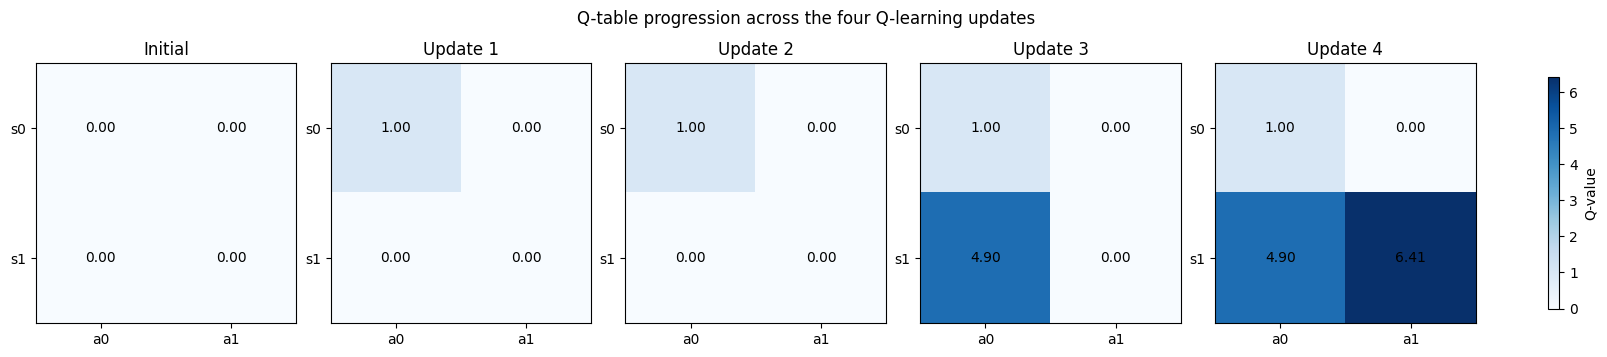

In [ ]:
# Lecture 9D: Q-learning
import matplotlib.pyplot as plt
import numpy as np

GAMMA = 0.9
ALPHA = 1.0

states = ["s0", "s1"]
actions = ["a0", "a1"]

# Each tuple is: (current state, action, next state, reward)
agent_path = [
    ("s0", "a0", "s0", 1),
    ("s0", "a1", "s1", 0),
    ("s1", "a0", "s0", 4),
    ("s1", "a1", "s1", 2),
]


def create_empty_q_table(states, actions):
    return {state: {action: 0.0 for action in actions} for state in states}


def copy_q_table(q_table):
    return {state: values.copy() for state, values in q_table.items()}


def q_table_to_array(q_table, states, actions):
    return np.array([[q_table[state][action] for action in actions] for state in states])


def print_q_table(q_table, states, actions):
    header = "       " + "  ".join(f"{action:>6}" for action in actions)
    print(header)
    for state in states:
        row = "  ".join(f"{q_table[state][action]:>6.2f}" for action in actions)
        print(f"{state:>4}   {row}")
    print()


q_table = create_empty_q_table(states, actions)
snapshots = [("Initial", copy_q_table(q_table))]

print("Initial Q-table:")
print_q_table(q_table, states, actions)

for step_number, (state, action, next_state, reward) in enumerate(agent_path, start=1):
    # Look one step ahead and use the best Q-value available in the next state.
    max_next_q = max(q_table[next_state].values())
    old_q_value = q_table[state][action]
    target = reward + GAMMA * max_next_q

    # With alpha = 1.0, the new Q-value becomes the full target.
    q_table[state][action] = old_q_value + ALPHA * (target - old_q_value)
    snapshots.append((f"Update {step_number}", copy_q_table(q_table)))

    print(
        f"Update {step_number}: ({state}, {action}) -> {next_state} with reward {reward}"
    )
    print_q_table(q_table, states, actions)

print("Final Q-table:")
print_q_table(q_table, states, actions)

# Visualize how the 2x2 Q-table changes after each update.
figure, axes = plt.subplots(1, len(snapshots), figsize=(16, 3.5), constrained_layout=True)
max_q_value = max(np.max(q_table_to_array(snapshot, states, actions)) for _, snapshot in snapshots)

for axis, (title, snapshot) in zip(axes, snapshots):
    table_array = q_table_to_array(snapshot, states, actions)
    image = axis.imshow(table_array, cmap="Blues", vmin=0, vmax=max_q_value)
    axis.set_title(title)
    axis.set_xticks(range(len(actions)))
    axis.set_xticklabels(actions)
    axis.set_yticks(range(len(states)))
    axis.set_yticklabels(states)

    for row_index in range(len(states)):
        for column_index in range(len(actions)):
            axis.text(
                column_index,
                row_index,
                f"{table_array[row_index, column_index]:.2f}",
                ha="center",
                va="center",
                color="black",
            )

figure.colorbar(image, ax=axes, shrink=0.75, label="Q-value")
figure.suptitle("Q-table progression across the four Q-learning updates")
plt.show()


After the four updates, I ended up with a final Q-table of `Q(s0,a0)=1.0`, `Q(s0,a1)=0.0`, `Q(s1,a0)=4.9`, and `Q(s1,a1)=6.41`. The highest value is `Q(s1,a1)`, and to me that makes sense because the action gives an immediate reward of `2`, but it also keeps the agent in `s1`, where there is already a strong future option available through `a0`. What I like about this example is that it shows pretty clearly that Q-learning is not only reacting to the reward happening right now. It is also looking ahead through the `gamma * max Q(s',a')` term and using that estimate of future reward in the current update. I think that connects well to the closed-loop medication delivery system I described earlier, because a dosing decision should not be evaluated only by the patient's next reading, but by the future state that decision is likely to create. Q-learning is considered model-free because the agent does not need the full environment model ahead of time, and instead it learns directly from the transitions and rewards it experiences.
